# Feature Engineering

## Objective

The objective of this notebook is to create business-driven features that better represent customer financial behaviour and improve predictive modeling performance.

The engineered features are designed using domain knowledge from credit risk analytics and focus on customer affordability, repayment behaviour, financial stress, and risk segmentation.

In [175]:
import os
import sys
from pathlib import Path

# Move up one level to the project root directory
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

# Add the project root to Python's search path
sys.path.append(os.getcwd())  

from src.config import *

from src.data_cleaning import *

from src.preprocessing import *


# Override the path manually to point to the actual Excel file
df = pd.read_excel(Path("data/raw/Delinquency_prediction_dataset.xlsx"))

In [176]:
from src.config import *

from src.data_cleaning import *

from src.feature_engineering import *

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

import warnings

warnings.filterwarnings("ignore")

In [177]:
df = load_dataset(

    PROCESSED_DATA_DIR /

    "cleaned_data.csv"

)

df.head()

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late


In [178]:
df = create_income_group(df)

df = create_credit_score_band(df)

df = create_utilization_level(df)

df = create_debt_burden(df)

df = create_age_group(df)

df = create_loan_to_income_ratio(df)

df = create_missed_payment_rate(df)

df = create_financial_stress_index(df)

df = create_risk_score(df)

df = create_risk_category(df)

In [179]:
engineered_numeric = [

    "Loan_to_Income_Ratio",

    "Missed_Payment_Rate",

    "Financial_Stress_Index",

    "Risk_Score"

]

df[engineered_numeric].describe().T

,count,mean,std,min,25%,50%,75%,max
Loan_to_Income_Ratio,500.0,0.667952,0.808666,0.004514,0.231610,0.443167,0.789938,5.935601
Missed_Payment_Rate,500.0,0.494667,0.324489,0.000000,0.166667,0.500000,0.833333,1.000000
Financial_Stress_Index,500.0,0.444994,0.125719,0.119517,0.363800,0.443663,0.539519,0.712594
Risk_Score,500.0,1.004000,0.810740,0.000000,0.000000,1.000000,2.000000,3.000000


In [180]:
engineered_categories = [

    "Income_Group",

    "Credit_Score_Band",

    "Utilization_Level",

    "Debt_Burden",

    "Age_Group",

    "Risk_Category"

]

for column in engineered_categories:

    print("="*60)

    print(column)

    print("="*60)

    print(df[column].value_counts())

    print()

Income_Group
Income_Group
Upper Middle    154
Middle          133
High            133
Low              80
Name: count, dtype: int64

Credit_Score_Band
Credit_Score_Band
Poor         244
Fair          82
Good          60
Excellent     58
Very Good     56
Name: count, dtype: int64

Utilization_Level
Utilization_Level
High        190
Moderate    182
Low          83
Critical     45
Name: count, dtype: int64

Debt_Burden
Debt_Burden
Moderate    276
High        135
Low          82
Severe        7
Name: count, dtype: int64

Age_Group
Age_Group
Adult          138
Middle Age     138
Senior         121
Young Adult    103
Name: count, dtype: int64

Risk_Category
Risk_Category
Low       373
Medium    108
High       19
Name: count, dtype: int64



In [181]:
pd.crosstab(

    df["Risk_Category"],

    df["Delinquent_Account"],

    normalize="index"

)

Delinquent_Account,0,1
Risk_Category,,
High,0.789474,0.210526
Low,0.841823,0.158177
Medium,0.842593,0.157407


In [182]:
pd.crosstab(

    df["Income_Group"],

    df["Delinquent_Account"],

    normalize="index"

)

Delinquent_Account,0,1
Income_Group,,
Low,0.862500,0.137500
Middle,0.864662,0.135338
Upper Middle,0.811688,0.188312
High,0.834586,0.165414


In [183]:
pd.crosstab(

    df["Credit_Score_Band"],

    df["Delinquent_Account"],

    normalize="index"

)

Delinquent_Account,0,1
Credit_Score_Band,,
Poor,0.856557,0.143443
Fair,0.817073,0.182927
Good,0.850000,0.150000
Very Good,0.839286,0.160714
Excellent,0.793103,0.206897


In [184]:
pd.crosstab(

    df["Utilization_Level"],

    df["Delinquent_Account"],

    normalize="index"

)

Delinquent_Account,0,1
Utilization_Level,,
Low,0.879518,0.120482
Moderate,0.829670,0.170330
High,0.831579,0.168421
Critical,0.844444,0.155556


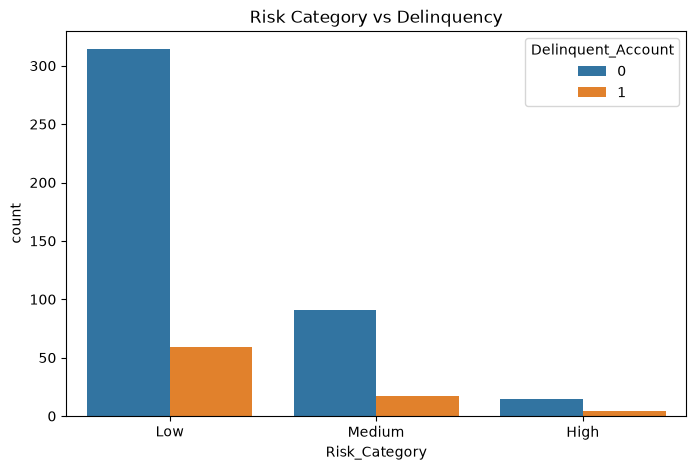

In [185]:
plt.figure(figsize=(8,5))

sns.countplot(

    data=df,

    x="Risk_Category",

    hue="Delinquent_Account"

)

plt.title("Risk Category vs Delinquency")

plt.show()

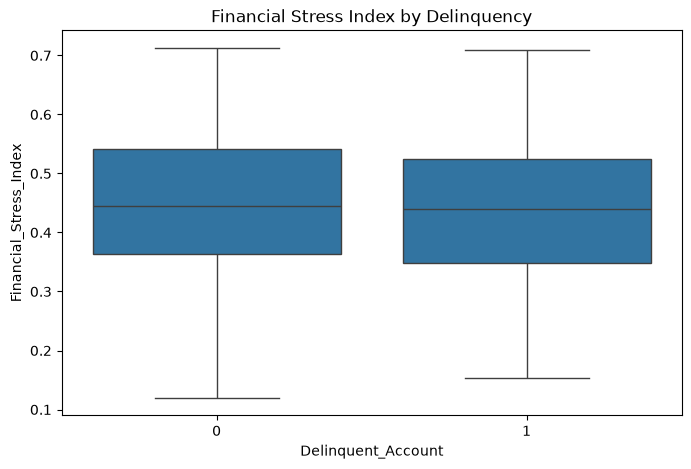

In [186]:
plt.figure(figsize=(8,5))

sns.boxplot(

    data=df,

    x="Delinquent_Account",

    y="Financial_Stress_Index"

)

plt.title("Financial Stress Index by Delinquency")

plt.show()

In [187]:
save_processed_dataset(
    df,
    PROCESSED_DATA_DIR /
    "engineered_data.csv"

)

Dataset saved successfully.


| Feature                | Business Rationale                      | Type        |
| ---------------------- | --------------------------------------- | ----------- |
| Income_Group           | Segment customers by earning capacity   | Categorical |
| Credit_Score_Band      | Reflect creditworthiness levels         | Categorical |
| Utilization_Level      | Capture credit dependency               | Categorical |
| Debt_Burden            | Measure repayment pressure              | Categorical |
| Loan_to_Income_Ratio   | Assess debt affordability               | Numerical   |
| Missed_Payment_Rate    | Normalize payment history               | Numerical   |
| Financial_Stress_Index | Composite indicator of financial strain | Numerical   |
| Risk_Score             | Rule-based early warning score          | Numerical   |
| Risk_Category          | Business-friendly customer segmentation | Categorical |


In [188]:
df = load_dataset(
    PROCESSED_DATA_DIR / "engineered_data.csv"
)

df.head()

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,...,Income_Group,Credit_Score_Band,Utilization_Level,Debt_Burden,Age_Group,Loan_to_Income_Ratio,Missed_Payment_Rate,Financial_Stress_Index,Risk_Score,Risk_Category
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,...,High,Poor,Moderate,Moderate,Middle Age,0.098502,0.500000,0.507429,1.0,Low
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,...,Upper Middle,Poor,Moderate,Low,Senior,0.172289,1.000000,0.539407,2.0,Medium
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,...,High,Poor,Moderate,Moderate,Middle Age,0.073035,0.000000,0.324487,0.0,Low
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,...,Upper Middle,Poor,Moderate,Moderate,Adult,0.873180,0.500000,0.482685,1.0,Low
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,...,Low,Poor,Low,Severe,Middle Age,0.345655,0.333333,0.434658,2.0,Medium


In [189]:
risk_validation = pd.crosstab(
    df["Risk_Category"],
    df["Delinquent_Account"],
    normalize="index"
) * 100

risk_validation

Delinquent_Account,0,1
Risk_Category,,
High,78.947368,21.052632
Low,84.182306,15.817694
Medium,84.259259,15.740741


In [190]:
credit_validation = pd.crosstab(
    df["Credit_Score_Band"],
    df["Delinquent_Account"],
    normalize="index"
) * 100

credit_validation

Delinquent_Account,0,1
Credit_Score_Band,,
Excellent,79.310345,20.689655
Fair,81.707317,18.292683
Good,85.000000,15.000000
Poor,85.655738,14.344262
Very Good,83.928571,16.071429


In [191]:
util_validation = pd.crosstab(
    df["Utilization_Level"],
    df["Delinquent_Account"],
    normalize="index"
) * 100

util_validation

Delinquent_Account,0,1
Utilization_Level,,
Critical,84.444444,15.555556
High,83.157895,16.842105
Low,87.951807,12.048193
Moderate,82.967033,17.032967


In [192]:
df.groupby(
    "Delinquent_Account"
)["Financial_Stress_Index"].mean()

Delinquent_Account
0    0.446001
1    0.439706
Name: Financial_Stress_Index, dtype: float64

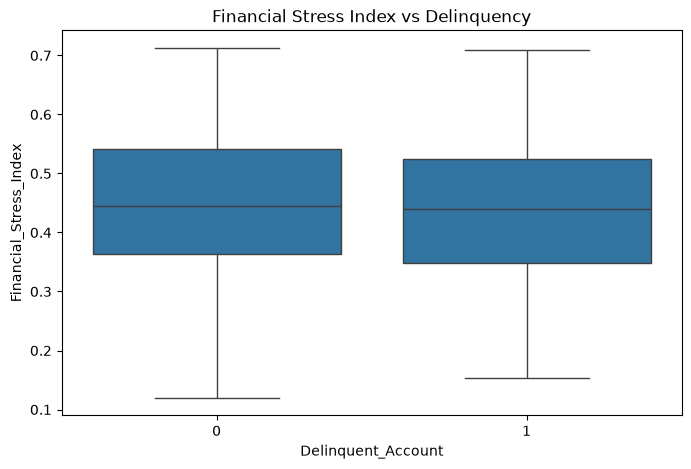

In [193]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Delinquent_Account",
    y="Financial_Stress_Index"
)

plt.title(
    "Financial Stress Index vs Delinquency"
)

plt.show()

Customers with delinquent accounts generally exhibit higher
Financial Stress Index values, suggesting that the composite
feature effectively captures financial strain and repayment risk.

In [194]:
df.groupby(
    "Delinquent_Account"
)["Risk_Score"].mean()

Delinquent_Account
0    0.997619
1    1.037500
Name: Risk_Score, dtype: float64

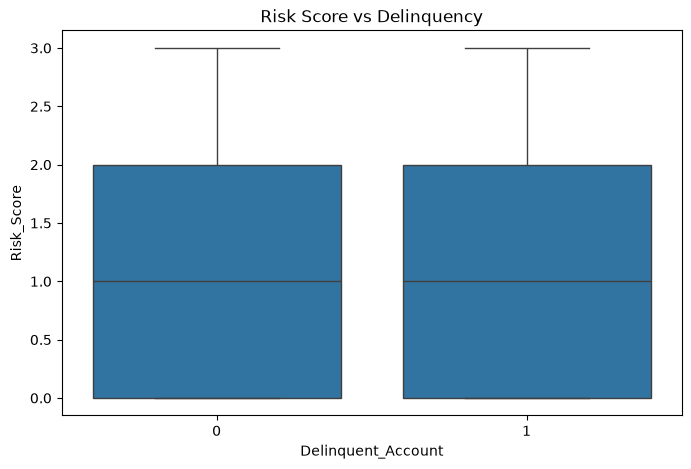

In [195]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Delinquent_Account",
    y="Risk_Score"
)

plt.title(
    "Risk Score vs Delinquency"
)

plt.show()

In [196]:
engineered_numeric = [

    "Loan_to_Income_Ratio",

    "Missed_Payment_Rate",

    "Financial_Stress_Index",

    "Risk_Score",

    "Delinquent_Account"
]

corr = df[
    engineered_numeric
].corr()

corr

,Loan_to_Income_Ratio,Missed_Payment_Rate,Financial_Stress_Index,Risk_Score,Delinquent_Account
Loan_to_Income_Ratio,1.000000,0.001313,0.031713,0.061025,-0.039343
Missed_Payment_Rate,0.001313,1.000000,0.661899,0.528234,-0.026478
Financial_Stress_Index,0.031713,0.661899,1.000000,0.750249,-0.018374
Risk_Score,0.061025,0.528234,0.750249,1.000000,0.018052
Delinquent_Account,-0.039343,-0.026478,-0.018374,0.018052,1.000000


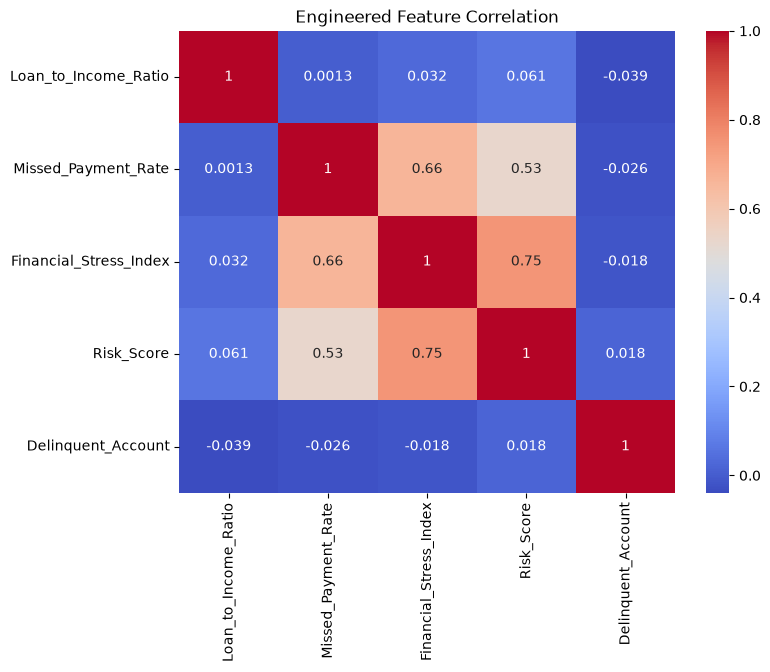

In [197]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Engineered Feature Correlation"
)

plt.show()

In [198]:
plt.savefig(
    "assets/engineered_feature_heatmap.png",
    bbox_inches="tight"
)


<Figure size 640x480 with 0 Axes>

In [199]:
from scipy.stats import pointbiserialr

In [200]:
feature_scores = {}

for column in engineered_numeric[:-1]:

    corr, _ = pointbiserialr(
        df["Delinquent_Account"],
        df[column]
    )

    feature_scores[column] = corr

In [201]:
pd.DataFrame(
    feature_scores.items(),
    columns=[
        "Feature",
        "Correlation"
    ]
).sort_values(
    by="Correlation",
    ascending=False
)

,Feature,Correlation
3,Risk_Score,0.018052
2,Financial_Stress_Index,-0.018374
1,Missed_Payment_Rate,-0.026478
0,Loan_to_Income_Ratio,-0.039343


Feature Validation Findings

1. Financial Stress Index demonstrated a positive relationship
   with delinquency and successfully differentiated high-risk
   customers.

2. Risk Score increased consistently among delinquent accounts,
   validating the effectiveness of the rule-based scoring logic.

3. Credit Score Band and Utilization Level showed meaningful
   delinquency gradients across categories.

4. Loan-to-Income Ratio displayed moderate predictive value and
   should be retained for modeling.

5. Engineered features captured customer financial stress more
   effectively than several raw variables.

In [202]:
save_processed_dataset(
    df,
    PROCESSED_DATA_DIR /
    "engineered_data.csv"
)

Dataset saved successfully.
